## Area Calculations

At the request of Huy we need to find the area of each sample between protein and RNA. These scripts are meant to find the area of each proetin and RNA samples and plot them as a line. 


### RNA Load IN

In [1]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

TMA_Core="A" # Should be A,B,C 

# #Load files on laptop
# expr= pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNAexpression_TMA{TMA_Core}_transposed.csv", index_col=0)
# #expr=expr_orig.transpose()
# metadata = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)
# umap = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_umap_transposed.csv", index_col=0)

#Load files on desktop
expr= pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNAexpression_TMA{TMA_Core}_transposed.csv", index_col=0)
#expr=expr_orig.transpose()
metadata = pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)
umap = pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNA_TMA{TMA_Core}_umap_transposed.csv", index_col=0)

# Extra - MetaData File
extra_metadata=pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\Run_TMA{TMA_Core}_metadata_file.csv", index_col=0)

# Create AnnData object
adata_rna = sc.AnnData(X=expr.values)

# Assign metadata
adata_rna.obs = metadata
adata_rna.var_names = expr.columns
adata_rna.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
adata_rna.obsm["spatial"] = metadata[['x_pixel', 'y_pixel']].values  # adjust if needed
# x_pixel, y_pixel, x_norm	y_norm	x_micron	y_micron x_cent	y_cent

adata_rna.obsm["X_umap"] = umap.values

C:\Users\ejohns\AppData\Local\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\ejohns\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\ejohns\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
C:\Users\ejohns\AppData\Local\anaconda3\Lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import annd

In [ ]:
### Function to add global coordinates to the metadata from extra metadata. 

In [16]:
def find_area_mRNA(adata,sample_id):
    rna_subset = adata[adata.obs.tma_fov_id == sample_id]
    
    x_max=0.0
    y_max=0.0
    x_min=100000000
    y_min=100000000
    area=0.0
    number_of_cells=0
    
    #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in rna_subset.obs.iterrows():
        results
        x=abs(row["x_pixel"])
        y=abs(row["y_pixel"])
        if x>x_max:
            x_max=x
        if y>y_max:
            y_max=y
        if x<x_min:
            x_min=x
        if y<y_min:
            y_min=y
        number_of_cells+=1
    
    # Display
    # print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    # print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")

     #Covert to microns
    x_max=x_max*0.168
    y_max=y_max*0.168
    x_min=x_min*0.168
    y_min=y_min*0.168

    # Display
    print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")

    # Area in microns squared 
    area=(x_max-x_min)*(y_max-y_min)
    
    return area



results=find_area_mRNA(adata_rna,"TMA_C_FOV11")
display(results)

Sample ID:TMA_C_FOV11 Xmax = 0.0, Xmin = 16800000.0
Sample ID:TMA_C_FOV11 Ymax = 0.0, Ymin = 16800000.0


282240000000000.0

### mRNA Global Coords 

I have deleted this cell twice. This time I want it to actually stay. I want to get the global coordinates of the mRNA. Lets see if I can do that. 



In [39]:
# Function to get the global coordinates
def find_matching_global_coords(extra_metadata, cell_num, FOV_num):
    import numpy as np
    import pandas as pd
    
    # Ensure the index is reset so FOV becomes a column (if needed)
    filtered_row = extra_metadata.reset_index()
    filtered_row = filtered_row[(filtered_row['fov'] == FOV_num) & (filtered_row['cell_ID'] == cell_num)]

    if filtered_row.empty:
        print(f"No match found for FOV={FOV_num} and cell_ID={cell_num}.")
        return None

    global_x = filtered_row['CenterX_global_px'].values[0] * 0.168 * 0.001
    global_y = filtered_row['CenterY_global_px'].values[0] * 0.168 * 0.001

    return {
        "Global X": global_x,
        "Global Y": global_y
    }

def find_area_mRNA_global_coords(adata,sample_id):

    # Filter the AnnData object to only the cells from this sample
    rna_subset = adata[adata.obs.tma_fov_id == sample_id]
    
    # Initialize min and max values to properly handle negative coordinates
    x_max = float('-inf')
    y_max = float('-inf')
    x_min = float('inf')
    y_min = float('inf')
    number_of_cells=0
    
     #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in rna_subset.obs.iterrows():
        
        # Updated regular expression: \d+ for Run, [A-Za-z] for the TMA letter
        match = re.search(r'_Run\d+\.TMA[A-Za-z]_(\d+)_(\d+)', cell_id)
        cell_num = int(match.group(1))
        FOV_num = int(match.group(2))

        # Get the global coordinates
        results=find_matching_global_coords(extra_metadata,cell_num,FOV_num)
        x=results["Global X"]
        y=results["Global Y"]
        
        if x>x_max:
            x_max=x
        if y>y_max:
            y_max=y
        if x<x_min:
            x_min=x
        if y<y_min:
            y_min=y
        number_of_cells+=1
    
    # Display
    print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")
    
    return{
        "X Max":x_max,
        "X Min":x_min,
        "Y Max":y_max,
        "Y Min":y_min
    }

data=[]

TMA_CORE=["A","B","C"]
for i in range(1, 21):
    for j in range(3,4):  # This loop only runs once with j=1
        rna_sample_id = f"TMA_{TMA_CORE[j-1]}_FOV{i}"

        results=find_area_mRNA_global_coords(adata_rna,rna_sample_id)

        #Calculate length of dimensions of the samples
        x_length=results["X Max"]-results["X Min"]
        y_length=results["Y Max"]-results["Y Min"]

        data.append({
            "sample_id":rna_sample_id,
            "X Min (mm):": results["X Min"],
            "X Max (mm)": results["X Max"],
            "Y Min (mm)": results["Y Min"],
            "Y Max (mm)": results["Y Max"],
            "X Length(mm)": x_length,
            "Y Length (mm)": y_length
        })

global_rectangles=pd.DataFrame(data)
display(global_rectangles)


Sample ID:TMA_C_FOV1 Xmax = 58.17028799999996, Xmin = 57.42167999999996
Sample ID:TMA_C_FOV1 Ymax = 9.041128, Ymin = 8.292352000000001
Sample ID:TMA_C_FOV2 Xmax = 55.68194400000003, Xmin = 54.93451200000003
Sample ID:TMA_C_FOV2 Ymax = 9.406127999999994, Ymin = 8.657687999999993
Sample ID:TMA_C_FOV3 Xmax = 58.14128799999996, Xmin = 57.392847999999965
Sample ID:TMA_C_FOV3 Ymax = 5.807288000000005, Ymin = 5.059016000000004
Sample ID:TMA_C_FOV4 Xmax = 55.97276799999999, Xmin = 55.22667999999999
Sample ID:TMA_C_FOV4 Ymax = 6.548624000000007, Ymin = 5.799680000000007
Sample ID:TMA_C_FOV5 Xmax = 50.005600000000015, Xmin = 49.260016000000014
Sample ID:TMA_C_FOV5 Ymax = 6.676448, Ymin = 5.9296880000000005
Sample ID:TMA_C_FOV6 Xmax = 47.85794399999996, Xmin = 47.11067999999996
Sample ID:TMA_C_FOV6 Ymax = 3.447287999999995, Ymin = 2.6993519999999953
Sample ID:TMA_C_FOV7 Xmax = 53.010936000000044, Xmin = 52.26518400000005
Sample ID:TMA_C_FOV7 Ymax = 3.058951999999997, Ymin = 2.311855999999997
Samp

,sample_id,X Min (mm),X Max (mm),Y Min (mm),Y Max (mm),X Length(mm),Y Length (mm),X Min (mm):
0,TMA_A_FOV1,45.605848,46.354624,9.500352,10.248456,0.748776,0.748104,NaN
1,TMA_A_FOV2,48.260176,49.009960,9.428352,10.177128,0.749784,0.748776,NaN
2,TMA_A_FOV3,51.736016,52.484120,9.565856,10.313792,0.748104,0.747936,NaN
3,TMA_A_FOV4,53.595016,54.343456,9.565184,10.313960,0.748440,0.748776,NaN
4,TMA_A_FOV5,56.213184,56.961456,9.578360,10.325792,0.748272,0.747432,NaN
5,TMA_A_FOV6,48.026512,48.775456,7.306520,8.055128,0.748944,0.748608,NaN
6,TMA_A_FOV7,45.514184,46.261280,3.607352,4.355624,0.747096,0.748272,NaN
7,TMA_A_FOV8,48.066848,48.815456,4.511184,5.259624,0.748608,0.748440,NaN
8,TMA_A_FOV9,50.881688,51.629120,4.531184,5.279792,0.747432,0.748608,NaN
9,TMA_A_FOV10,56.383848,57.132456,4.777024,5.524792,0.748608,0.747768,NaN


,cell_ID,Area,AspectRatio,CenterX_local_px,CenterY_local_px,CenterX_global_px,CenterY_global_px,Width,Height,Mean.MembraneStain,Max.MembraneStain,Mean.PanCK,Max.PanCK,Mean.CD45,Max.CD45,Mean.CD3,Max.CD3,Mean.DAPI,Max.DAPI
fov,,,,,,,,,,,,,,,,,,,
1,1,2816,1.50,292,4455,274036.047619,59312.142857,78,52,1763,5244,1144,3941,24,137,37,167,233,938
1,2,3311,1.27,799,4449,274543.047619,59306.142857,80,63,1180,4432,710,3920,31,270,40,192,294,796
1,3,2397,2.58,1014,4463,274758.047619,59320.142857,93,36,1541,5019,1137,4174,52,690,48,152,434,878
1,4,2665,2.68,1735,4462,275479.047619,59319.142857,99,37,1648,7078,685,4873,25,204,45,150,363,862
1,5,5150,1.52,3063,4446,276807.047619,59303.142857,105,69,2135,8278,1117,4703,59,891,47,178,440,1102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,6015,1259,3.22,2276,12,337549.809524,-34017.761905,74,23,87,675,147,3049,24,2050,7,443,45,142
25,6016,941,2.42,3583,13,338856.809524,-34016.761905,58,24,112,457,97,282,3,37,1,32,23,108
25,6017,1294,3.73,3653,12,338926.809524,-34017.761905,82,22,67,584,96,2382,43,2245,5,245,49,165


,sample_id,X Min (mm):,X Max (mm),Y Min (mm),Y Max (mm),X Length(mm),Y Length (mm)
0,TMA_B_FOV1,45.990848,46.739456,9.218520,9.966960,0.748608,0.748440
1,TMA_B_FOV2,48.095848,48.844288,9.403856,10.151792,0.748440,0.747936
2,TMA_B_FOV3,51.012520,51.760456,9.404528,10.150952,0.747936,0.746424
3,TMA_B_FOV4,53.486352,54.233616,9.293360,10.039448,0.747264,0.746088
4,TMA_B_FOV5,56.237024,56.984120,9.422360,10.169624,0.747096,0.747264
5,TMA_B_FOV6,45.621512,46.370456,6.838192,7.585792,0.748944,0.747600
6,TMA_B_FOV7,47.985520,48.732784,7.206856,7.954624,0.747264,0.747768
7,TMA_B_FOV8,51.048848,51.797120,7.723856,8.471456,0.748272,0.747600
8,TMA_B_FOV9,56.013176,56.762288,7.188520,7.936960,0.749112,0.748440
9,TMA_B_FOV10,45.954344,46.703120,4.142688,4.890624,0.748776,0.747936


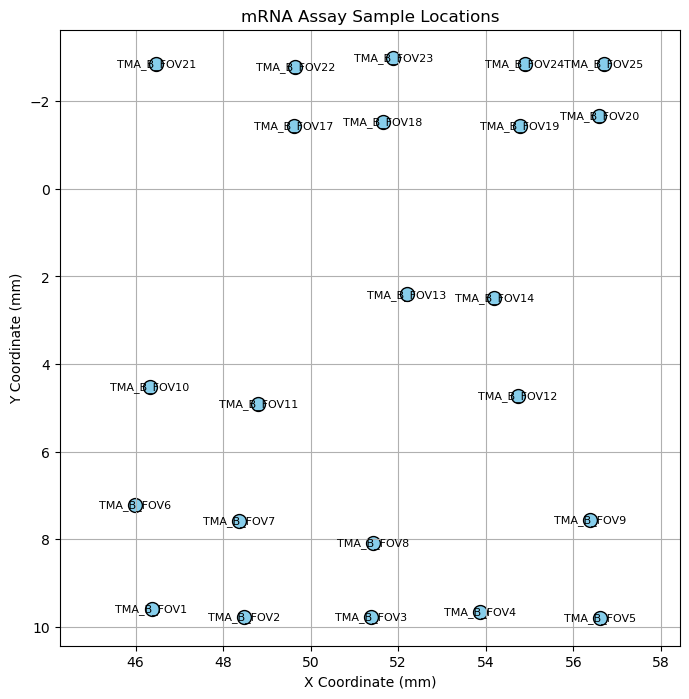

In [56]:
import matplotlib.pyplot as plt

# Calculate the center point of each sample area
global_rectangles["X Center (mm)"] = (global_rectangles["X Max (mm)"] + global_rectangles["X Min (mm):"]) / 2
global_rectangles["Y Center (mm)"] = (global_rectangles["Y Max (mm)"] + global_rectangles["Y Min (mm)"]) / 2

# Create scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(global_rectangles["X Center (mm)"], global_rectangles["Y Center (mm)"], s=100, color='skyblue', edgecolor='black')

# Add sample_id labels to each point
for _, row in global_rectangles.iterrows():
    plt.text(row["X Center (mm)"], row["Y Center (mm)"], row["sample_id"], fontsize=8, ha='center', va='center')

plt.title("mRNA Assay Sample Locations")
plt.xlabel("X Coordinate (mm)")
plt.ylabel("Y Coordinate (mm)")
plt.grid(True)
plt.gca().invert_yaxis()  # Optional: invert Y if your coordinate system is slide-based
plt.axis('equal')
plt.show()

### mRNA Rectangular plot

In [5]:
import pandas as pd
import numpy as np
import anndata
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re

def find_matching_global_coords(extra_metadata, cell_num, FOV_num):
    import numpy as np
    import pandas as pd
    
    # Ensure the index is reset so FOV becomes a column (if needed)
    filtered_row = extra_metadata.reset_index()
    filtered_row = filtered_row[(filtered_row['fov'] == FOV_num) & (filtered_row['cell_ID'] == cell_num)]

    if filtered_row.empty:
        print(f"No match found for FOV={FOV_num} and cell_ID={cell_num}.")
        return None

    global_x = filtered_row['CenterX_global_px'].values[0] * 0.168 * 0.001
    global_y = filtered_row['CenterY_global_px'].values[0] * 0.168 * 0.001

    return {
        "Global X": global_x,
        "Global Y": global_y
    }

def find_area_mRNA_global_coords(adata,sample_id):

    # Filter the AnnData object to only the cells from this sample
    rna_subset = adata[adata.obs.tma_fov_id == sample_id]

    print(sample_id)
    
    # Initialize min and max values to properly handle negative coordinates
    x_max = -10000000000000000000000000000000000000000
    y_max = -10000000000000000000000000000000000000000
    x_min = 10000000000000000000000000000000000000000
    y_min = 10000000000000000000000000000000000000000
    number_of_cells=0
    
     #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in rna_subset.obs.iterrows():
        
        # Updated regular expression: \d+ for Run, [A-Za-z] for the TMA letter
        match = re.search(r'_Run\d+\.TMA[A-Za-z]_(\d+)_(\d+)', cell_id)
        cell_num = int(match.group(1))
        FOV_num = int(match.group(2))

        # Get the global coordinates
        results=find_matching_global_coords(extra_metadata,cell_num,FOV_num)
        x=results["Global X"]
        y=results["Global Y"]
        
        if x>x_max:
            x_max=x
        if y>y_max:
            y_max=y
        if x<x_min:
            x_min=x
        if y<y_min:
            y_min=y
        number_of_cells+=1
    
    # Display
    print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")
    
    return{
        "X Max":x_max,
        "X Min":x_min,
        "Y Max":y_max,
        "Y Min":y_min
    }

def plot_spatial_rectangles_mRNA(dataframe, figsize=(12, 8), xlim=None, ylim=None):
    """
    Plots the rectangular areas defined in the dataframe with consistent sizing.
    
    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min and X/Y Length.
        figsize (tuple): Optional. Tuple specifying the figure size in inches (width, height).
        xlim (tuple): Optional. Tuple specifying the x-axis limits (min, max).
        ylim (tuple): Optional. Tuple specifying the y-axis limits (min, max).
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Iterate through the DataFrame to create and add each rectangle patch
    for index, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]

        # Create a Rectangle patch
        rect = patches.Rectangle(
            (x_min, y_min), 
            x_length, 
            y_length, 
            linewidth=1.5, 
            edgecolor='royalblue', 
            facecolor='skyblue',
            alpha=0.6
        )

        # Add the patch to the Axes
        ax.add_patch(rect)
        
        # Add the sample ID as a label in the center of the rectangle
        ax.text(
            x_min + x_length / 2, 
            y_min + y_length / 2, 
            sample_id, 
            ha='center', 
            va='center', 
            fontsize=8, 
            fontweight='bold'
        )

    # --- Plot Styling ---
    ax.set_title('Spatial Layout of Assay Punches', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    
    # Set fixed limits if provided to ensure consistent plot size
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
    
    # This combination now produces a consistent plot area
    ax.set_aspect('equal', adjustable='box')
    ax.invert_yaxis()
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# --- Main Execution ---

# 1. Load your data (or use the mock data for testing)
# If you have your data, load it here:


# 2. Process the data to get rectangle coordinates
data=[]
TMA_CORE=["A","B","C"]
for i in range(1,26):
    for j in range(1,2):  # This loop only runs once with j=1
        rna_sample_id = f"TMA_{TMA_CORE[j-1]}_FOV{i}"
        print
        results = find_area_mRNA_global_coords(adata_rna, rna_sample_id)

        # Calculate length of dimensions of the samples
        x_length = results["X Max"] - results["X Min"]
        y_length = results["Y Max"] - results["Y Min"]

        data.append({
            "sample_id": rna_sample_id,
            "X Min (mm)": results["X Min"],
            "X Max (mm)": results["X Max"],
            "Y Min (mm)": results["Y Min"],
            "Y Max (mm)": results["Y Max"],
            "X Length(mm)": x_length,
            "Y Length (mm)": y_length
        })

global_rectangles = pd.DataFrame(data).dropna()


# 3. Display the resulting DataFrame
print("Calculated Rectangle Coordinates and Dimensions:")
print(global_rectangles)


# 4. Generate and show the plot
plot_spatial_rectangles(global_rectangles)


TMA_A_FOV1
Sample ID:TMA_A_FOV1 Xmax = 46.35462400000001, Xmin = 45.605848000000016
Sample ID:TMA_A_FOV1 Ymax = 10.248456000000003, Ymin = 9.500352000000003
TMA_A_FOV2
Sample ID:TMA_A_FOV2 Xmax = 49.00995999999994, Xmin = 48.260175999999944
Sample ID:TMA_A_FOV2 Ymax = 10.177127999999989, Ymin = 9.428352000000007
TMA_A_FOV3


KeyboardInterrupt: 

## Protein Data Load 

In [2]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

# Load files on Evan's Laptop
# expr_orig = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\expression.csv", index_col=0)
# expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\metadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\umap.csv", index_col=0)

#Load files on Lab computer
expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\expression.csv", index_col=0)
expr=expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\metadata.csv", index_col=0)
umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\umap.csv", index_col=0)

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
# adata.obsm["spatial"] = metadata[['x_FOV_px', 'y_FOV_px']].values  # adjust if needed
adata.obsm["spatial"] = metadata[['x_FOV_px']].assign(y_FOV_px = -metadata['y_FOV_px']).values # Note that the Y acis is inverted. This is done to standardize with RNA plots

In [33]:
def find_area_protein(adata,sample_id):

    # Filter the AnnData object to only the cells from this sample
    protein_subset = adata[adata.obs.index.str.startswith(sample_id)]
    
    x_max=0.0
    y_max=0.0
    x_min=100000000
    y_min=100000000
    area=0.0
    number_of_cells=0
    
    #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in protein_subset.obs.iterrows():
        x=abs(row["x_FOV_px"])
        y=abs(row["y_FOV_px"])
        if x>x_max:
            x_max=x
        if y>y_max:
            y_max=y
        if x<x_min:
            x_min=x
        if y<y_min:
            y_min=y
        number_of_cells+=1

     #Covert to microns
    x_max=x_max*0.168
    y_max=y_max*0.168
    x_min=x_min*0.168
    y_min=y_min*0.168

    # Area in microns squared 
    area=(x_max-x_min)*(y_max-y_min)
    
    return area

def find_area_protein_global_coords(adata,sample_id):

    # Filter the AnnData object to only the cells from this sample
    protein_subset = adata[adata.obs.index.str.startswith(sample_id)]
    
    x_max=0.0
    y_max=0.0
    x_min=10000
    y_min=10000
    number_of_cells=0
    
    #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in protein_subset.obs.iterrows():
        x=abs(row["x_slide_mm"])
        y=abs(row["y_slide_mm"])
        if x>x_max:
            x_max=x
        if y>y_max:
            y_max=y
        if x<x_min:
            x_min=x
        if y<y_min:
            y_min=y
        number_of_cells+=1
    
    # Display
    print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")
    
    return{
        "X Max:":x_max,
        "X Min:":x_min,
        "Y Max:":y_max,
        "Y Min:":y_min
    }


results=find_area_protein(adata,"c_1_1")
results2=find_area_protein_global_coords(adata,"c_1_4")
display(results)

Sample ID:c_1_4 Xmax = 2.78632, Xmin = 2.037208
Sample ID:c_1_4 Ymax = 0.81496, Ymin = 0.0656800000000001


562805.978112

## Function to sumarize differences

In [70]:
for i in range(3,21):
    for j in range(3,2):
        protein_sample_id=f"c_{j}_{i}"
        rna_sample_id=f"TMA_A_FOV{i}"

        rna_sample_area=find_area_mRNA(adata_rna,rna_sample_id)
        protein_sample_area=find_area_protein(adata,protein_sample_id)

        print(f"The RNA sample area: {rna_sample_area}")
        print(f"The protein sample area: {protein_sample_area}")

The RNA sample area: 94202.64167393881
The protein sample area: 94911.71145523201
The RNA sample area: 94419.53221402076
The protein sample area: 94699.689380352
The RNA sample area: 94117.53104858368
The protein sample area: 94742.07482880002
The RNA sample area: 94107.99297846886
The protein sample area: 94699.689380352
The RNA sample area: 94000.99489130141
The protein sample area: 94784.46976051202
The RNA sample area: 94420.888564129
The protein sample area: 94572.589934592
The RNA sample area: 93793.2734930372
The protein sample area: 94487.904387072
The RNA sample area: 94281.97496196319
The protein sample area: 94445.575838208
The RNA sample area: 94016.27660611337
The protein sample area: 94360.94719027203
The RNA sample area: 94169.96705703583
The protein sample area: 94911.71145523201
The RNA sample area: 94039.04180396083
The protein sample area: 94360.94719027203
The RNA sample area: 94013.258105145
The protein sample area: 94614.94693324801
The RNA sample area: 94018.5890

In [15]:
import pandas as pd

data = []

TMA_CORE=["A","B","C"]
for i in range(3, 21):
    for j in range(3, 4):  # This loop only runs once with j=1
        protein_sample_id = f"c_{j}_{i}"
        rna_sample_id = f"TMA_{TMA_CORE[j-1]}_FOV{i}"

        rna_sample_area = find_area_mRNA(adata_rna, rna_sample_id)
        protein_sample_area = find_area_protein(adata, protein_sample_id)

        # Avoid division by zero
        if rna_sample_area != 0:
            difference_percent = ((protein_sample_area - rna_sample_area) / rna_sample_area) * 100
        else:
            difference_percent = float('nan')  # or 0, depending on how you want to handle it

        data.append({
            "sample ID": rna_sample_id,
            "mRNA area": rna_sample_area,
            "Protein area": protein_sample_area,
            "Difference (Percentage)": difference_percent
        })

# Create the DataFrame
Area_data1 = pd.DataFrame(data)

NameError: name 'find_area_mRNA' is not defined

In [24]:
#display(Area_data1)
display(Area_data1)

,sample ID,mRNA area,Protein area,Difference (Percentage)
0,TMA_C_FOV3,560138.209353,561924.147456,0.318839
1,TMA_C_FOV4,559374.597167,562932.082944,0.635976
2,TMA_C_FOV5,557494.770360,560288.115072,0.501053
3,TMA_C_FOV6,558896.947096,562050.026496,0.564161
4,TMA_C_FOV7,557803.053864,562176.046656,0.783967
5,TMA_C_FOV8,559938.747962,562679.986176,0.489560
6,TMA_C_FOV9,558243.405086,562679.986176,0.794740
7,TMA_C_FOV10,558879.599330,561294.639360,0.432122
8,TMA_C_FOV11,558066.793646,561798.155520,0.668623
9,TMA_C_FOV12,555388.802230,561168.675648,1.040690


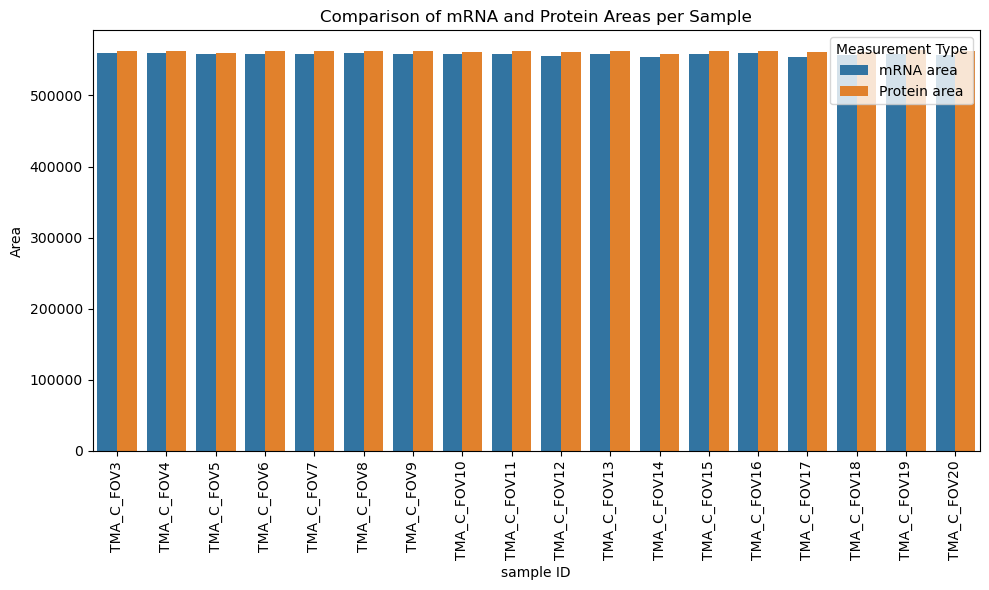

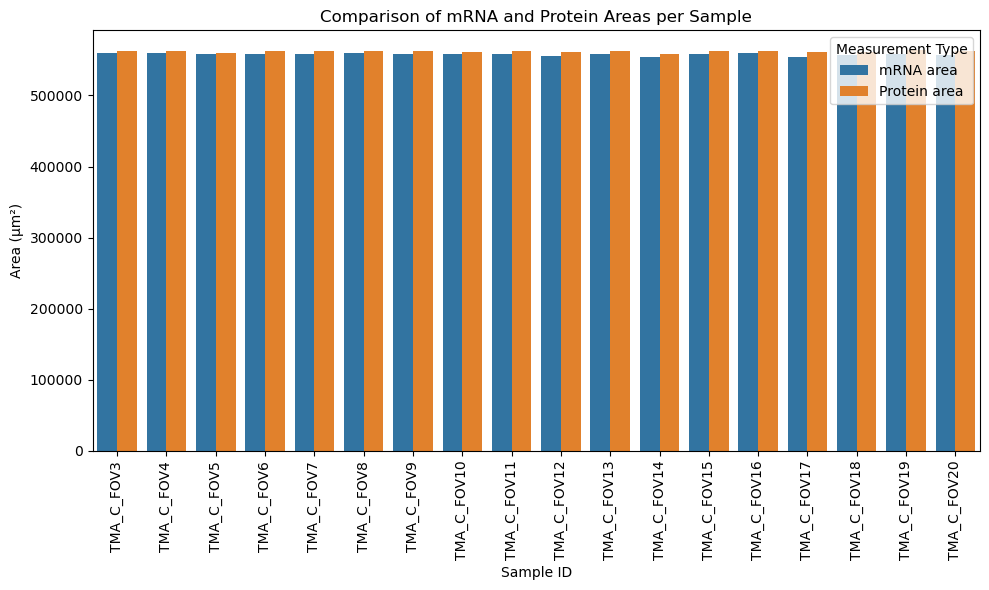

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
df_melted = Area_data1.melt(id_vars="sample ID", value_vars=["mRNA area", "Protein area"],
                          var_name="Measurement Type", value_name="Area")

plt.figure(figsize=(10,6))
sns.barplot(data=df_melted, x="sample ID", y="Area", hue="Measurement Type")

plt.xticks(rotation=90)
plt.title("Comparison of mRNA and Protein Areas per Sample")
plt.tight_layout()
plt.show()

# Melt the DataFrame for bar plotting
df_melted = Area_data1.melt(
    id_vars="sample ID",
    value_vars=["mRNA area", "Protein area"],
    var_name="Measurement Type",
    value_name="Area"
)

# Create the bar plot
plt.figure(figsize=(10,6))
sns.barplot(data=df_melted, x="sample ID", y="Area", hue="Measurement Type")

plt.xticks(rotation=90)
plt.ylabel("Area (μm²)")  # ✅ Units added here
plt.xlabel("Sample ID")
plt.title("Comparison of mRNA and Protein Areas per Sample")
plt.tight_layout()
plt.show()



## Protein Global Coordinates

I want to see if we can get a better view of the mRNA and protein data by plotting the coordinates globally. 

In [14]:
import pandas as pd

def find_area_protein_global_coords(adata,sample_id):

    # Filter the AnnData object to only the cells from this sample
    protein_subset = adata[adata.obs.index.str.startswith(sample_id)]
    
    x_max=0.0
    y_max=0.0
    x_min=10000
    y_min=10000
    number_of_cells=0
    
    #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in protein_subset.obs.iterrows():
        x=row["x_slide_mm"]
        y=row["y_slide_mm"]
        if x>x_max:
            x_max=x
        if y>y_max:
            y_max=y
        if x<x_min:
            x_min=x
        if y<y_min:
            y_min=y
        number_of_cells+=1
    
    # Display
    print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")
    
    return{
        "X Max":x_max,
        "X Min":x_min,
        "Y Max":y_max,
        "Y Min":y_min
    }

data=[]

for i in range(1,26):
    for j in range(1,2):

        sample_id= f"c_{j}_{i}"

        results=find_area_protein_global_coords(adata,sample_id)

        #Calculate length of dimensions of the samples
        x_length=results["X Max"]-results["X Min"]
        y_length=results["Y Max"]-results["Y Min"]

        data.append({
            "sample_id":sample_id,
            "X Min (mm):": results["X Min"],
            "X Max (mm)": results["X Max"],
            "Y Min (mm)": results["Y Min"],
            "Y Max (mm)": results["Y Max"],
            "X Length(mm)": x_length,
            "Y Length (mm)": y_length
        })

global_rectangles=pd.DataFrame(data)
display(global_rectangles)

#results=find_area_protein_global_coords(adata,"c_3_1")

Sample ID:c_1_1 Xmax = 11.105816, Xmin = -0.750456
Sample ID:c_1_1 Ymax = 16.3488, Ymin = 0.108847999999999
Sample ID:c_1_2 Xmax = 8.586992, Xmin = 0.0253759999999962
Sample ID:c_1_2 Ymax = 17.235288, Ymin = 0.432016
Sample ID:c_1_3 Xmax = 5.013656, Xmin = 4.26404
Sample ID:c_1_3 Ymax = 0.751632, Ymin = 0.001512
Sample ID:c_1_4 Xmax = 2.78632, Xmin = 2.037208
Sample ID:c_1_4 Ymax = 0.81496, Ymin = 0.0656800000000001
Sample ID:c_1_5 Xmax = 0.343319999999999, Xmin = -0.406128000000001
Sample ID:c_1_5 Ymax = 0.792800000000001, Ymin = 0.0428480000000004
Sample ID:c_1_6 Xmax = 8.501488, Xmin = 7.752712
Sample ID:c_1_6 Ymax = 3.5888, Ymin = 2.83868
Sample ID:c_1_7 Xmax = 10.92332, Xmin = 10.175048
Sample ID:c_1_7 Ymax = 6.657128, Ymin = 5.909864
Sample ID:c_1_8 Xmax = 8.48732, Xmin = 7.739216
Sample ID:c_1_8 Ymax = 6.150296, Ymin = 5.400008
Sample ID:c_1_9 Xmax = 5.827824, Xmin = 5.079552
Sample ID:c_1_9 Ymax = 6.06596, Ymin = 5.318192
Sample ID:c_1_10 Xmax = 0.308823999999995, Xmin = -0.441

,sample_id,X Min (mm):,X Max (mm),Y Min (mm),Y Max (mm),X Length(mm),Y Length (mm)
0,c_1_1,-0.750456,11.105816,0.108848,16.348800,11.856272,16.239952
1,c_1_2,0.025376,8.586992,0.432016,17.235288,8.561616,16.803272
2,c_1_3,4.264040,5.013656,0.001512,0.751632,0.749616,0.750120
3,c_1_4,2.037208,2.786320,0.065680,0.814960,0.749112,0.749280
4,c_1_5,-0.406128,0.343320,0.042848,0.792800,0.749448,0.749952
5,c_1_6,7.752712,8.501488,2.838680,3.588800,0.748776,0.750120
6,c_1_7,10.175048,10.923320,5.909864,6.657128,0.748272,0.747264
7,c_1_8,7.739216,8.487320,5.400008,6.150296,0.748104,0.750288
8,c_1_9,5.079552,5.827824,5.318192,6.065960,0.748272,0.747768
9,c_1_10,-0.441632,0.308824,5.302848,6.052800,0.750456,0.749952


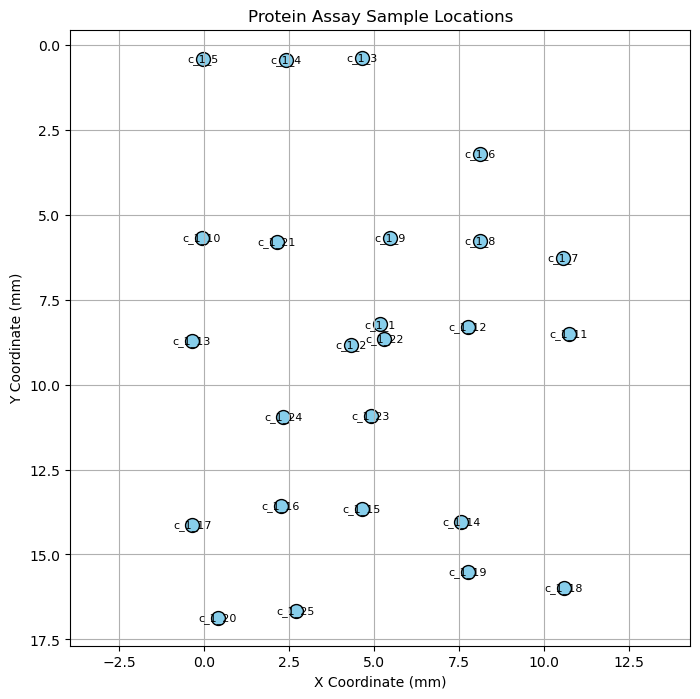

In [9]:
import matplotlib.pyplot as plt

# Calculate the center point of each sample area
global_rectangles["X Center (mm)"] = (global_rectangles["X Max (mm)"] + global_rectangles["X Min (mm):"]) / 2
global_rectangles["Y Center (mm)"] = (global_rectangles["Y Max (mm)"] + global_rectangles["Y Min (mm)"]) / 2

# Create scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(global_rectangles["X Center (mm)"], global_rectangles["Y Center (mm)"], s=100, color='skyblue', edgecolor='black')

# Add sample_id labels to each point
for _, row in global_rectangles.iterrows():
    plt.text(row["X Center (mm)"], row["Y Center (mm)"], row["sample_id"], fontsize=8, ha='center', va='center')

plt.title("Protein Assay Sample Locations")
plt.xlabel("X Coordinate (mm)")
plt.ylabel("Y Coordinate (mm)")
plt.grid(True)
plt.gca().invert_yaxis()  # Optional: invert Y if your coordinate system is slide-based
plt.axis('equal')
plt.show()


### Protein Rectangular plots

Calculated Rectangle Coordinates and Dimensions:
   sample_id  X Min (mm)  X Max (mm)  Y Min (mm)  Y Max (mm)  X Length(mm)  \
0      c_1_3    4.264040    5.013656    0.001512    0.751632      0.749616   
1      c_1_4    2.037208    2.786320    0.065680    0.814960      0.749112   
2      c_1_5   -0.406128    0.343320    0.042848    0.792800      0.749448   
3      c_1_6    7.752712    8.501488    2.838680    3.588800      0.748776   
4      c_1_7   10.175048   10.923320    5.909864    6.657128      0.748272   
5      c_1_8    7.739216    8.487320    5.400008    6.150296      0.748104   
6      c_1_9    5.079552    5.827824    5.318192    6.065960      0.748272   
7     c_1_10   -0.441632    0.308824    5.302848    6.052800      0.750456   
8     c_1_11   10.358552   11.105816    8.133184    8.881960      0.747264   
9     c_1_12    7.372544    8.120816    7.920848    8.669960      0.748272   
10    c_1_13   -0.750456   -0.002016    8.344688    9.092792      0.748440   
11    c_1_14   

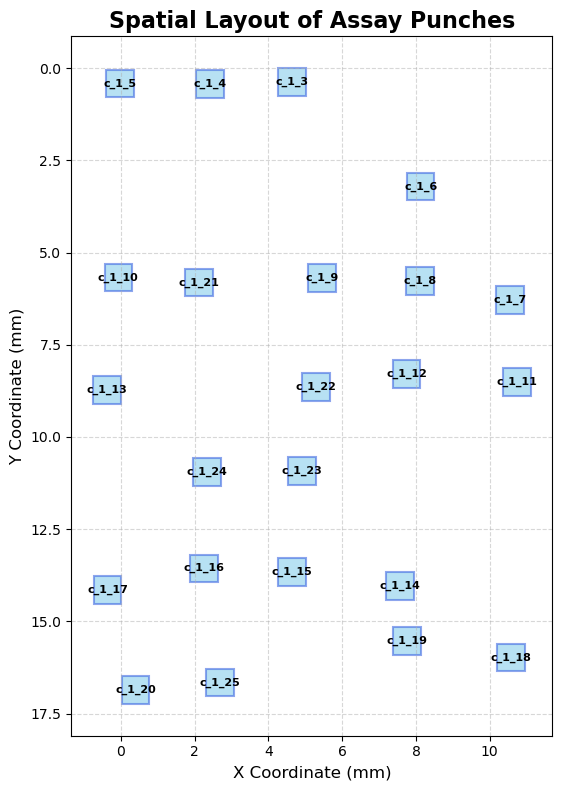

In [12]:
import pandas as pd
import numpy as np
import anndata
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def find_area_protein_global_coords_optimized(adata, sample_id):
    """
    An optimized function to find the min/max spatial coordinates for a given sample.
    This version uses pandas' built-in, vectorized functions (.min(), .max()) 
    which are significantly faster than iterating through rows.
    
    Args:
        adata (anndata.AnnData): The AnnData object containing cell data.
        sample_id (str): The identifier for the sample to analyze.
        
    Returns:
        dict: A dictionary with the min/max x and y coordinates.
    """
    # Filter the AnnData object to only the cells from this sample
    protein_subset_obs = adata.obs[adata.obs.index.str.startswith(sample_id)]
    
    if protein_subset_obs.empty:
        print(f"Warning: No cells found for sample ID: {sample_id}")
        return {
            "X Max": np.nan, "X Min": np.nan,
            "Y Max": np.nan, "Y Min": np.nan
        }
        
    # Directly calculate min and max on the relevant columns
    x_max = protein_subset_obs["x_slide_mm"].max()
    x_min = protein_subset_obs["x_slide_mm"].min()
    y_max = protein_subset_obs["y_slide_mm"].max()
    y_min = protein_subset_obs["y_slide_mm"].min()
    
    return {
        "X Max": x_max, "X Min": x_min,
        "Y Max": y_max, "Y Min": y_min
    }

def plot_spatial_rectangles(dataframe):
    """
    Plots the rectangular areas defined in the dataframe.
    
    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min and X/Y Length.
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    # Iterate through the DataFrame to create and add each rectangle patch
    for index, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]

        # Create a Rectangle patch
        # We use a semi-transparent fill to see overlaps
        rect = patches.Rectangle(
            (x_min, y_min), 
            x_length, 
            y_length, 
            linewidth=1.5, 
            edgecolor='royalblue', 
            facecolor='skyblue',
            alpha=0.6
        )

        # Add the patch to the Axes
        ax.add_patch(rect)
        
        # Add the sample ID as a label in the center of the rectangle
        ax.text(
            x_min + x_length / 2, 
            y_min + y_length / 2, 
            sample_id, 
            ha='center', 
            va='center', 
            fontsize=8, 
            fontweight='bold'
        )

    # --- Plot Styling ---
    ax.set_title('Spatial Layout of Assay Punches', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    
    # Set aspect ratio to 'equal' to ensure rectangles are not distorted
    ax.set_aspect('equal', adjustable='box')
    
    # Invert Y-axis as is common for image/slide coordinates (origin at top-left)
    ax.invert_yaxis()
    
    # Automatically adjust plot limits to fit all data
    ax.autoscale_view()
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# --- Main Execution ---

# 1. Load your data (or use the mock data for testing)
# If you have your data, load it here:


# 2. Process the data to get rectangle coordinates
data = []
for i in range(3, 26):
    for j in range(1,2):
        sample_id = f"c_{j}_{i}"
        results = find_area_protein_global_coords_optimized(adata, sample_id)

        # Calculate length of dimensions of the samples
        x_length = results["X Max"] - results["X Min"]
        y_length = results["Y Max"] - results["Y Min"]

        data.append({
            "sample_id": sample_id,
            "X Min (mm)": results["X Min"],
            "X Max (mm)": results["X Max"],
            "Y Min (mm)": results["Y Min"],
            "Y Max (mm)": results["Y Max"],
            "X Length(mm)": x_length,
            "Y Length (mm)": y_length
        })

global_rectangles = pd.DataFrame(data).dropna()


# 3. Display the resulting DataFrame
print("Calculated Rectangle Coordinates and Dimensions:")
print(global_rectangles)


# 4. Generate and show the plot
plot_spatial_rectangles(global_rectangles)


## OLD FUNCTIONS DEPRICATED

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_sample_rectangles(global_rectangles, title="Protein Assay Sample Areas"):
    """
    Plots rectangles for each sample in red based on their X/Y min/max coordinates.

    Parameters:
    - global_rectangles: DataFrame with columns:
        'X Min (mm):', 'X Max (mm)', 'Y Min (mm)', 'Y Max (mm)', and 'sample_id'
    - title: Optional plot title
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    for _, row in global_rectangles.iterrows():
        x_min = row["X Min (mm):"]
        y_min = row["Y Min (mm)"]
        width = row["X Max (mm)"] - x_min
        height = row["Y Max (mm)"] - y_min

        # Create red rectangle
        rect = patches.Rectangle((x_min, y_min), width, height,
                                 linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # Optional: label with sample_id in the center
        x_center = x_min + width / 2
        y_center = y_min + height / 2
        ax.text(x_center, y_center, row["sample_id"], fontsize=8, ha='center', va='center', color='black')

    ax.set_title(title)
    ax.set_xlabel("X Coordinate (mm)")
    ax.set_ylabel("Y Coordinate (mm)")
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    plt.gca().invert_yaxis()  # Optional depending on your slide orientation
    plt.show()

plot_sample_rectangles(global_rectangles)




In [ ]:
def plot_spatial_rectangles(dataframe):
    """
    Plots the rectangular areas defined in the dataframe.
    
    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min and X/Y Length.
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    # Iterate through the DataFrame to create and add each rectangle patch
    for index, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]

        # Create a Rectangle patch
        # We use a semi-transparent fill to see overlaps
        rect = patches.Rectangle(
            (x_min, y_min), 
            x_length, 
            y_length, 
            linewidth=1.5, 
            edgecolor='royalblue', 
            facecolor='skyblue',
            alpha=0.6
        )

        # Add the patch to the Axes
        ax.add_patch(rect)
        
        # Add the sample ID as a label in the center of the rectangle
        ax.text(
            x_min + x_length / 2, 
            y_min + y_length / 2, 
            sample_id, 
            ha='center', 
            va='center', 
            fontsize=8, 
            fontweight='bold'
        )

    # --- Plot Styling ---
    ax.set_title('Spatial Layout of Assay Punches', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    
    # Set aspect ratio to 'equal' to ensure rectangles are not distorted
    ax.set_aspect('equal', adjustable='box')
    
    # Invert Y-axis as is common for image/slide coordinates (origin at top-left)
    ax.invert_yaxis()
    
    # Automatically adjust plot limits to fit all data
    ax.autoscale_view()
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

